# _Exploratory Data Analysis (EDA)_
---
**Author:** Francisco Antonio Alamo Rios  
**Registration number:** 2508983

---


In [1]:
# Imports
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Steps

- Data loading and basic inspection
- Infer data types
- Check missing values and duplicates
- Get a rough idea of column types (numeric / categorical / text / etc.)
- Look at distributions and correlations for numeric features
- Distribution checks
- Recommendations


### Load dataset (CSV/Excel supported)
- Show shape, sample rows, info, and descriptive statistics
- infer data types

In [2]:
# Values that can be tuned agentic robot
COMMON_NA = ['?', 'NA', 'N/A', 'NULL', '']
smalldata = 500
mediumdata = 10000
highdimensionality = 50

path = 'data/london_houses.csv' # dataset
report = {} # dictionary to store EDA results

if not Path(path).exists():
    raise FileNotFoundError(f"Dataset not found: {path}")

# load data
def load_dataset(path):
    path_lower = str(path).lower()

    if path_lower.endswith(".csv"):
        return pd.read_csv(path, na_values=COMMON_NA, keep_default_na=True)
    elif path_lower.endswith((".xlsx", ".xls")):
        return pd.read_excel(path, na_values=COMMON_NA, keep_default_na=True)
    else:
        raise ValueError("Unsupported file type")
    
df = load_dataset(path)
report['dataset'] = path
report['columns'] = df.shape[1]
report['rows'] = df.shape[0]
report['dtypes'] = df.dtypes.astype(str).to_dict()

FileNotFoundError: Dataset not found: data/london_houses.csv

In [ ]:
# Infer schema
def infer_schema(df, cat_max_unique=20):
    out = {}

    for col in df.columns:
        s = df[col]
        kind = s.dtype.kind

        if s.isna().all():
            out[col] = "all_missing"
            continue

        if kind in "ifc":  # i=int, f=float, c=complex
            out[col] = "numeric"
            continue

        if kind == "M":  # M=datetime
            out[col] = "datetime"
            continue

        if kind == "b":  # b=boolean
            out[col] = "boolean"
            continue

        # categorical vs text
        n_unique = s.dropna().nunique()
        out[col] = "categorical" if n_unique <= cat_max_unique else "text"

    return out

report['schema'] = infer_schema(df)
report["schema_counts"] = pd.Series(report["schema"]).value_counts().to_dict()
df.sample(5) 


,Address,Neighborhood,Bedrooms,Bathrooms,Square Meters,Building Age,Garden,Garage,Floors,Property Type,Heating Type,Balcony,Interior Style,View,Materials,Building Status,Price (£)
814,177 Piccadilly Circus,Greenwich,1,3,206,17,No,No,2,Detached House,Underfloor Heating,Low-level Balcony,Industrial,City,Laminate Flooring,Renovated,2060000
531,137 King's Road,Shoreditch,5,2,63,94,Yes,Yes,1,Apartment,Underfloor Heating,Low-level Balcony,Modern,Street,Laminate Flooring,Renovated,462000
538,85 Strand,Camden,3,1,97,4,No,No,3,Detached House,Central Heating,No Balcony,Modern,Sea,Granite,Old,1261000
373,33 Bond Street,Soho,4,1,152,33,Yes,Yes,1,Detached House,Underfloor Heating,Low-level Balcony,Industrial,Garden,Granite,Renovated,2128000
562,36 Strand,Soho,1,2,76,58,No,Yes,1,Semi-Detached,Central Heating,High-level Balcony,Industrial,City,Wood,Old,851200


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Address          1000 non-null   object
 1   Neighborhood     1000 non-null   object
 2   Bedrooms         1000 non-null   int64 
 3   Bathrooms        1000 non-null   int64 
 4   Square Meters    1000 non-null   int64 
 5   Building Age     1000 non-null   int64 
 6   Garden           1000 non-null   object
 7   Garage           1000 non-null   object
 8   Floors           1000 non-null   int64 
 9   Property Type    1000 non-null   object
 10  Heating Type     1000 non-null   object
 11  Balcony          1000 non-null   object
 12  Interior Style   1000 non-null   object
 13  View             1000 non-null   object
 14  Materials        1000 non-null   object
 15  Building Status  1000 non-null   object
 16  Price (£)        1000 non-null   int64 
dtypes: int64(6), object(11)
memory usa

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Address,1000,770,96 King's Road,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Neighborhood,1000,10,Kensington,114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bedrooms,1000.0,NaN,NaN,NaN,3.013,1.393834,1.0,2.0,3.0,4.0,5.0
Bathrooms,1000.0,NaN,NaN,NaN,2.003,0.808483,1.0,1.0,2.0,3.0,3.0
Square Meters,1000.0,NaN,NaN,NaN,149.627,58.0562,50.0,99.0,148.0,201.0,249.0
Building Age,1000.0,NaN,NaN,NaN,49.965,29.07086,1.0,24.0,50.0,76.0,99.0
Garden,1000,2,Yes,512,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Garage,1000,2,Yes,501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floors,1000.0,NaN,NaN,NaN,1.991,0.821946,1.0,1.0,2.0,3.0,3.0
Property Type,1000,3,Detached House,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Check missing values and duplicates
- Missingness per column (%)
- Duplicate rows (count and %)

In [ ]:
def missingness_report(df):
    out = []
    n = len(df)

    for col in df.columns:
        p = float(round(df[col].isna().sum() * 100 / n, 1)) if n else 0.0
        out.append((col, p))

    out.sort(key=lambda x: x[1], reverse=True)
    return out

# duplicates 
def duplicate_report(df):
    n = len(df)
    dup = int(df.duplicated().sum())
    pct = round(float(dup * 100 / n), 2) if n else 0.0
    return {"duplicate_rows": dup, "duplicate_pct": pct}

# unique values per column
def nunique_report(df, dropna=True):
    return df.nunique(dropna=dropna).astype(int).to_dict()

print(missingness_report(df))
print(duplicate_report(df))
print(nunique_report(df))
report['missingness'] = missingness_report(df)
report['duplicates'] = duplicate_report(df)
report['nunique'] = nunique_report(df)



[('Address', 0.0), ('Neighborhood', 0.0), ('Bedrooms', 0.0), ('Bathrooms', 0.0), ('Square Meters', 0.0), ('Building Age', 0.0), ('Garden', 0.0), ('Garage', 0.0), ('Floors', 0.0), ('Property Type', 0.0), ('Heating Type', 0.0), ('Balcony', 0.0), ('Interior Style', 0.0), ('View', 0.0), ('Materials', 0.0), ('Building Status', 0.0), ('Price (£)', 0.0)]
{'duplicate_rows': 0, 'duplicate_pct': 0.0}
{'Address': 770, 'Neighborhood': 10, 'Bedrooms': 5, 'Bathrooms': 3, 'Square Meters': 197, 'Building Age': 99, 'Garden': 2, 'Garage': 2, 'Floors': 3, 'Property Type': 3, 'Heating Type': 4, 'Balcony': 3, 'Interior Style': 4, 'View': 5, 'Materials': 4, 'Building Status': 3, 'Price (£)': 786}


In [ ]:
# Column profile table
table = pd.DataFrame({
    "dtype": report["dtypes"],
    "schema": report['schema'],
    "missing_rate": df.isna().mean(),
    "n_unique": df.nunique(dropna=True),
})

# add up to 3 example values per column (non-null)
examples = {}
for c in df.columns:
    vals = df[c].dropna().astype(str).head(3).tolist()
    examples[c] = ", ".join(vals)
table["examples"] = pd.Series(examples)

table.sort_values(["missing_rate", "n_unique"], ascending=[False, True]).head(30)

,dtype,schema,missing_rate,n_unique,examples
Garden,object,categorical,0.0,2,"No, Yes, No"
Garage,object,categorical,0.0,2,"No, No, Yes"
Bathrooms,int64,numeric,0.0,3,"3, 1, 3"
Floors,int64,numeric,0.0,3,"3, 1, 3"
Property Type,object,categorical,0.0,3,"Semi-Detached, Apartment, Semi-Detached"
Balcony,object,categorical,0.0,3,"High-level Balcony, High-level Balcony, No Bal..."
Building Status,object,categorical,0.0,3,"Renovated, Old, Renovated"
Heating Type,object,categorical,0.0,4,"Electric Heating, Central Heating, Central Hea..."
Interior Style,object,categorical,0.0,4,"Industrial, Industrial, Industrial"
Materials,object,categorical,0.0,4,"Marble, Laminate Flooring, Wood"


In [ ]:
miss = report["missingness"]  # list of (col, pct), already sorted desc
miss_top = [(c, p) for c, p in miss if p > 0][:15]

if not miss_top:
    print("No missing values detected.")
else:
    # reverse so biggest appears at the top of the chart
    cols = [c for c, _ in miss_top][::-1]
    pcts = [p for _, p in miss_top][::-1]

    plt.figure(figsize=(10, 6))
    plt.barh(cols, pcts)
    plt.title("Missingness (%): Top columns")
    plt.xlabel("Missing %")

    # optional labels
    for i, v in enumerate(pcts):
        plt.text(v + 0.2, i, str(v), va="center")

    plt.tight_layout()
    plt.show()

No missing values detected.


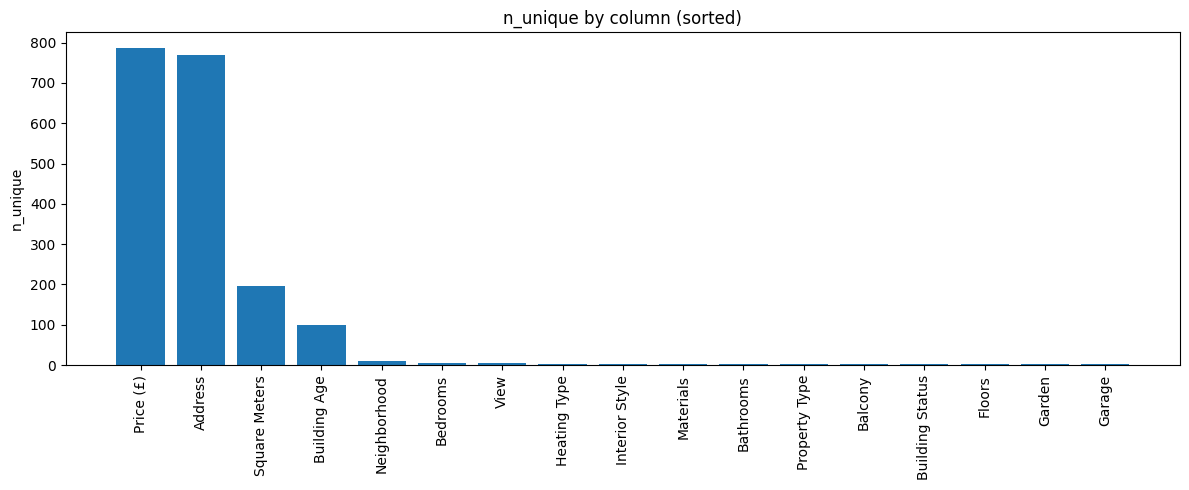

In [ ]:

nu = table["n_unique"].sort_values(ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(nu.index.astype(str), nu.values)
plt.title("n_unique by column (sorted)")
plt.ylabel("n_unique")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Imbalance checks & correlations
- Check the column to see if they are catergorical  (imbalance) or continuos (outlier)
- Imbalance checks for low-cardinality columns
- Outlier checks for numeric columns 
- Correlations

In [ ]:
def imbalance_report(df, schema, top_n=5, min_classes=2, max_classes=20): 
    out = []
    cat_cols = [c for c, t in schema.items() if t == "categorical"]

    for col in cat_cols:
        vc = df[col].value_counts(dropna=False)
        n_classes = int(vc.shape[0])

        if not (min_classes <= n_classes <= max_classes):
            continue

        total = int(vc.sum())
        if total == 0:
            continue

        majority_count = int(vc.iloc[0])
        minority_count = int(vc.iloc[-1])

        majority_pct = float(round(majority_count * 100 / total, 1))
        minority_pct = float(round(minority_count * 100 / total, 1))
        imbalance_ratio = float(round(majority_count / max(1, minority_count), 2))

        out.append({
            "column": col,
            "n_classes": n_classes,
            "majority_class_pct": majority_pct,
            "minority_class_pct": minority_pct,
            "imbalance_ratio": imbalance_ratio,
            "top_classes": [(str(k), int(v)) for k, v in vc.head(top_n).items()]
        })

    out.sort(key=lambda x: x["majority_class_pct"], reverse=True)
    return out


def outlier_report(df, schema, iqr_k=1.5):
    numeric_cols = [c for c, t in schema.items() if t == "numeric"]
    out = []
    n = len(df)

    for col in numeric_cols:
        s = df[col]
        x = s.dropna()

        if x.empty:
            continue

        q1 = float(x.quantile(0.25))
        q3 = float(x.quantile(0.75))
        iqr = q3 - q1

        # If IQR = 0, values are too concentrated to use IQR rule meaningfully
        if iqr == 0:
            continue

        lower = q1 - iqr_k * iqr
        upper = q3 + iqr_k * iqr

        mask = (s < lower) | (s > upper)
        n_out = int(mask.sum())
        pct_out = float(round((n_out * 100 / n), 2)) if n else 0.0

        out.append({
            "column": col,
            "outlier_rows": n_out,
            "outlier_pct": pct_out,
            "lower": float(round(lower, 4)),
            "upper": float(round(upper, 4))
        })

    # most outliers first
    out.sort(key=lambda d: d["outlier_pct"], reverse=True)
    return out

# Correlation report
def correlation_report(df, schema, top_n=20, min_abs_corr=0.0):
    numeric_cols = [c for c, t in schema.items() if t == "numeric"]

    if len(numeric_cols) < 2:
        return {"corr": None, "high_corr_pairs": []}

    corr = df[numeric_cols].corr(numeric_only=True)

    pairs = []
    for i in range(len(numeric_cols)):
        for j in range(i + 1, len(numeric_cols)):
            a = numeric_cols[i]
            b = numeric_cols[j]
            v = float(corr.loc[a, b])
            av = abs(v)

            if av < min_abs_corr:
                continue

            pairs.append({
                "col_a": a,
                "col_b": b,
                "corr": float(round(v, 4)),
                "abs_corr": float(round(av, 4)),
            })

    pairs.sort(key=lambda d: d["abs_corr"], reverse=True)
    return {"corr": corr, "high_corr_pairs": pairs[:top_n]}

report['imbalance'] = imbalance_report(df, report['schema'])
report['outliers'] = outlier_report(df, report['schema'])
cr = correlation_report(df, report["schema"])
report["correlation"] = cr["corr"]
report["high_corr_pairs"] = cr["high_corr_pairs"]

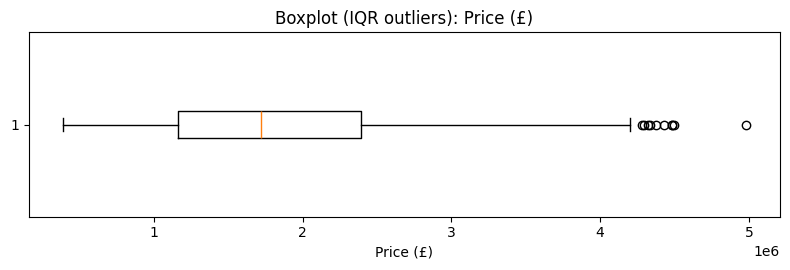

In [ ]:
outliers = report.get("outliers", [])
outliers_sorted = sorted(outliers, key=lambda d: d.get("outlier_pct", 0), reverse=True)
plot_outlier_cols = [d["column"] for d in outliers_sorted if d.get("outlier_pct", 0) > 0][:6]

if not plot_outlier_cols:
    print("No outlier-heavy numeric columns detected by IQR rule.")
else:
    for col in plot_outlier_cols:
        plt.figure(figsize=(8, 2.8))
        plt.boxplot(df[col].dropna(), vert=False)
        plt.title(f"Boxplot (IQR outliers): {col}")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

In [ ]:
# Column profile table (+ outliers)
table = pd.DataFrame({
    "dtype": report["dtypes"],
    "schema": report["schema"],
    "missing_rate": pd.Series(dict(report["missingness"])) / 100,  # from your missingness tuples
    "n_unique": pd.Series(report["nunique"]),
})

# examples
examples = {}
for c in df.columns:
    vals = df[c].dropna().astype(str).head(3).tolist()
    examples[c] = ", ".join(vals)
table["examples"] = pd.Series(examples)

# outliers -> map column -> outlier_rows
outlier_rows = {}
for d in report.get("outliers", []):
    outlier_rows[d["column"]] = d["outlier_rows"]
table["outlier_rows"] = pd.Series(outlier_rows).fillna(0).astype(int)

# outlier %
outlier_pct = {}
for d in report.get("outliers", []):
    outlier_pct[d["column"]] = d["outlier_pct"]
table["outlier_pct"] = pd.Series(outlier_pct)

table.sort_values(["outlier_rows", "n_unique"], ascending=[False, False]).head(30)

,dtype,schema,missing_rate,n_unique,examples,outlier_rows,outlier_pct
Price (£),int64,numeric,0.0,786,"2291200, 1476000, 1881600",10.0,1.0
Square Meters,int64,numeric,0.0,197,"179, 123, 168",0.0,0.0
Building Age,int64,numeric,0.0,99,"72, 34, 38",0.0,0.0
Bedrooms,int64,numeric,0.0,5,"2, 2, 5",0.0,0.0
Bathrooms,int64,numeric,0.0,3,"3, 1, 3",0.0,0.0
Floors,int64,numeric,0.0,3,"3, 1, 3",0.0,0.0
Address,object,text,0.0,770,"78 Regent Street, 198 Oxford Street, 18 Regent...",NaN,NaN
Neighborhood,object,categorical,0.0,10,"Notting Hill, Westminster, Soho",NaN,NaN
View,object,categorical,0.0,5,"Garden, City, Street",NaN,NaN
Heating Type,object,categorical,0.0,4,"Electric Heating, Central Heating, Central Hea...",NaN,NaN


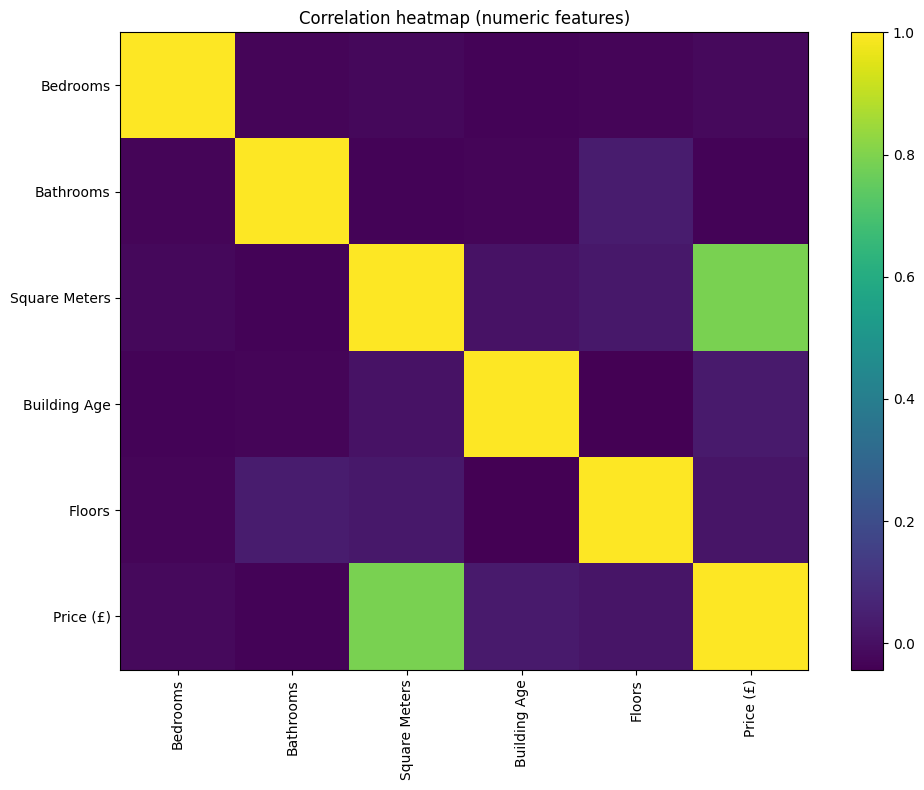

In [ ]:
# Plot correlation heatmap
corr = report.get("correlation", None)

if corr is None:
    print("Not enough numeric columns for correlation heatmap.")
else:
    plt.figure(figsize=(10, 8))
    plt.imshow(corr.values, aspect="auto")
    plt.title("Correlation heatmap (numeric features)")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

### Distribution checks
- Detect near-constant columns (low-variance / low-information features)
- Check skewness in numeric columns (asymmetry / heavy-tailed distributions)

In [ ]:
def near_constant_report(df, schema, min_non_null=1, max_unique=1):
    out = []
    for col, t in schema.items():
        if col not in df.columns:
            continue
        s = df[col].dropna()
        if len(s) < min_non_null:
            continue
        u = int(s.nunique())
        if u <= max_unique:
            out.append((col, u))
    return out

def skewness_report(df, schema):
    out = []
    for col, t in schema.items():
        if t != "numeric" or col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if len(s) == 0:
            continue
        sk = float(round(s.skew(), 3))
        out.append((col, sk))
    out.sort(key=lambda x: abs(x[1]), reverse=True)
    return out

report['near_constant'] = near_constant_report(df, report['schema'])
report['skewness'] = skewness_report(df, report['schema'])

In [ ]:
near_consts = report.get("near_constant", [])
plot_near_cols = [c for c, u in near_consts][:6]

if not plot_near_cols:
    print("No near-constant columns detected.")
else:
    for col in plot_near_cols:
        vc = df[col].value_counts(dropna=False).head(10)

        plt.figure(figsize=(8, 2.8))
        plt.bar([str(x) for x in vc.index], vc.values)
        plt.title(f"Near-constant column (top values): {col}")
        plt.ylabel("count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

skewness = report.get("skewness", [])
skew_sorted = sorted(skewness, key=lambda x: abs(x[1]), reverse=True)
plot_skew_cols = [c for c, sk in skew_sorted if abs(sk) >= 1.0][:6]

if not plot_skew_cols:
    print("No strongly skewed numeric columns detected")
else:
    for col in plot_skew_cols:
        plt.figure(figsize=(8, 2.8))
        plt.hist(df[col].dropna(), bins=30)
        plt.title(f"Histogram (skew={dict(skewness)[col]:.2f}): {col}")
        plt.xlabel(col)
        plt.ylabel("frequency")
        plt.tight_layout()
        plt.show()

No near-constant columns detected.
No strongly skewed numeric columns detected


### Ordinal & scale checks
- Detect ordinal-like numeric columns
- Check scale/range mismatch across numeric features

In [ ]:
def ordinal_report(df, schema, nunique_map, max_unique=20, int_tol=1e-6):
    out = []

    for col, t in schema.items():
        if t != "numeric" or col not in df.columns:
            continue

        u = int(nunique_map.get(col, 0))
        if u == 0 or u > max_unique:
            continue

        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if s.empty:
            continue

        # % of values that are "integer-like"
        frac_int = float(np.mean(np.abs(s - np.round(s)) <= int_tol))

        # Only keep if mostly integer-like and low unique count, suggesting possible ordinal encoding
        if frac_int >= 0.95:
            out.append((col, u, round(frac_int, 3)))

    # most discrete first
    out.sort(key=lambda x: x[1])
    return out

def scale_range_report(df, schema, top_n=10):
    out = []

    for col, t in schema.items():
        if t != "numeric" or col not in df.columns:
            continue

        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if s.empty:
            continue

        mn = float(s.min())
        mx = float(s.max())
        rg = float(mx - mn)

        ratio = None
        if mn > 0:
            ratio = float(mx / mn)

        out.append({
            "column": col,
            "min": round(mn, 6),
            "max": round(mx, 6),
            "range": round(rg, 6),
            "range_ratio": round(ratio, 3) if ratio is not None else None
        })

    out.sort(key=lambda d: d["range"], reverse=True)
    return out[:top_n]

report["ordinal"] = ordinal_report(df, report["schema"], report["nunique"], max_unique=20)
report['scale_range'] = scale_range_report(df, report['schema'])

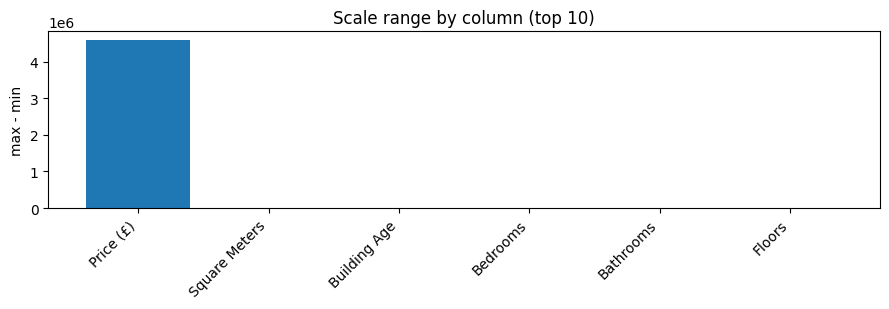

In [ ]:
# Plot scale range (numeric columns only)
scale = report.get("scale_range", [])
scale_sorted = sorted(scale, key=lambda d: d.get("range", 0), reverse=True)
plot_scale = scale_sorted[:10]

if not plot_scale:
    print("No scale range data to plot. Run report['scale_range'] first.")
else:
    cols = [d["column"] for d in plot_scale]
    ranges = [d["range"] for d in plot_scale]

    plt.figure(figsize=(9, 3.2))
    plt.bar(cols, ranges)
    plt.title("Scale range by column (top 10)")
    plt.ylabel("max - min")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### Target & task inference
- Infer a likely target column for ML
- Infer task type (classification vs regression) based on target type and cardinality

In [ ]:
def infer_target_column(df, schema, nunique):
    candidates = ["target", "label", "class", "y", "outcome"]
    lower_map = {c.lower(): c for c in df.columns}

    for k in candidates:
        if k in lower_map:
            return lower_map[k]

    # last column could be a good guess
    last = df.columns[-1]
    n = len(df)
    uniq = int(nunique.get(last, df[last].nunique(dropna=True)))

    #check if all columns are numeric - if so, pick the one with lowest cardinality as target
    if all(schema.get(c) == "numeric" for c in df.columns):
        num_cols = [c for c in df.columns if schema.get(c) == "numeric"]
        if not num_cols:
            return None
        min_col = min(num_cols, key=lambda c: nunique.get(c, float("inf")))
        return min_col
    # avoid guessing text columns as target
    if schema.get(last) == "text":
        return None

    # avoid almost-unique columns
    if n and (uniq / n) > 0.9:
        return None

    # low-cardinality columns are plausible targets
    if uniq <= highdimensionality:
        return last

    return last

def is_classification_target(series, schema_type, uniq):
    n = len(series)

    if schema_type in ["categorical", "boolean"]:
        return True

    if uniq <= highdimensionality:
        return True

    if n and (uniq / n) <= 0.05:
        return True

    return False

nunique = report.get("nunique", {})
target = infer_target_column(df, report["schema"], nunique)

if target is None:
    report["infer"] = {"target": None, "task_type": "unsupervised_or_unknown"}
else:
    uniq = int(nunique.get(target, df[target].nunique(dropna=True)))
    st = report["schema"].get(target, "")
    task = "classification" if is_classification_target(df[target], st, uniq) else "regression"
    report["infer"] = {"target": target, "task_type": task}

In [ ]:
report

{'dataset': 'data/london_houses.csv',
 'columns': 17,
 'rows': 1000,
 'dtypes': {'Address': 'object',
  'Neighborhood': 'object',
  'Bedrooms': 'int64',
  'Bathrooms': 'int64',
  'Square Meters': 'int64',
  'Building Age': 'int64',
  'Garden': 'object',
  'Garage': 'object',
  'Floors': 'int64',
  'Property Type': 'object',
  'Heating Type': 'object',
  'Balcony': 'object',
  'Interior Style': 'object',
  'View': 'object',
  'Materials': 'object',
  'Building Status': 'object',
  'Price (£)': 'int64'},
 'schema': {'Address': 'text',
  'Neighborhood': 'categorical',
  'Bedrooms': 'numeric',
  'Bathrooms': 'numeric',
  'Square Meters': 'numeric',
  'Building Age': 'numeric',
  'Garden': 'categorical',
  'Garage': 'categorical',
  'Floors': 'numeric',
  'Property Type': 'categorical',
  'Heating Type': 'categorical',
  'Balcony': 'categorical',
  'Interior Style': 'categorical',
  'View': 'categorical',
  'Materials': 'categorical',
  'Building Status': 'categorical',
  'Price (£)': 'nume

In [ ]:

# store important signals for planner in a simple dict
signals = {}

# Size
signals["rows"] = report["rows"]
signals["datasize"] = "small" if report["rows"] < smalldata else ("medium" if report["rows"] < mediumdata else "large")

# High dimensionality
signals["columns"] = report["columns"]
signals["high_dimensionality"] = report["columns"] >= highdimensionality  # pick your threshold

# Missingness
missingness = report.get("missingness", [])
max_missing = max(p for _, p in missingness) if missingness else 0.0
signals["any_missing"] = max_missing > 0
signals["max_missing_pct"] = max_missing

# Duplicates
dup_pct = report.get("duplicates", {}).get("duplicate_pct", 0.0)
signals["duplicates_high"] = dup_pct >= 5
signals["duplicate_pct"] = dup_pct

# Near-constants
signals["has_near_constant"] = len(report.get("near_constant", [])) > 0

# Outliers
outliers = report.get("outliers", [])
max_out = max(d.get("outlier_pct", 0) for d in outliers) if outliers else 0.0
signals["outliers_heavy"] = max_out >= 5
signals["max_outlier_pct"] = max_out

# Skewness
sk = report.get("skewness", [])
signals["has_skewness"] = len(sk) > 0
signals["skew_heavy_cols"] = [c for c, v in sk if abs(v) >= 1.0]

# Correlation (max abs corr)
pairs = report.get("high_corr_pairs", [])

if pairs:
    first = pairs[0]

    # tuple/list
    if isinstance(first, (list, tuple)) and len(first) >= 4:
        max_corr = max(p[3] for p in pairs)

    # dict
    elif isinstance(first, dict) and "abs_corr" in first:
        max_corr = max(p.get("abs_corr", 0) for p in pairs)

    else:
        max_corr = 0.0
else:
    corr = report.get("correlation", None)
    if corr is None or not hasattr(corr, "abs"):
        max_corr = 0.0
    else:
        m = corr.abs().values.copy()
        for i in range(len(m)):
            m[i, i] = 0
        max_corr = float(m.max())

signals["max_abs_corr"] = round(max_corr, 4)
signals["high_corr_present"] = max_corr >= 0.6

# Ordinal numeric columns
ord_cols = report.get("ordinal", [])
signals["has_ordinal"] = len(ord_cols) > 0
signals["ordinal_cols"] = [c for c, _, _ in ord_cols]

# Text-heavy dataset + schema mix summary
counts = report.get("schema_counts", {})
signals["n_numeric"] = counts.get("numeric", 0)
signals["n_categorical"] = counts.get("categorical", 0)
signals["n_text"] = counts.get("text", 0)

signals["text_cols"] = signals["n_text"]
signals["text_ratio"] = round(signals["n_text"] / max(1, report["columns"]), 2)
signals["text_heavy"] = (signals["text_ratio"] >= 0.5) or (signals["n_text"] >= 5)
signals["needs_text_eda"] = signals["text_heavy"]

# High-cardinality categoricals + one-hot risk
nunique = report.get("nunique", {})
cat_cols = [c for c, t in report.get("schema", {}).items() if t == "categorical" and c in nunique]

high_card = []
for c in cat_cols:
    u = int(nunique.get(c, 0))
    if u >= 50 or (signals["rows"] and (u / signals["rows"]) >= 0.05):
        high_card.append(c)

signals["high_cardinality_categoricals"] = high_card
signals["one_hot_risk"] = (len(high_card) >= 3) or (sum(int(nunique.get(c, 0)) for c in high_card) >= 200)

# Potential entity or ID leakage 
schema = report.get("schema", {})

entity_like = []
leaky_text = []

for c, u in nunique.items():
    if c not in df.columns:
        continue

    u = int(u)
    ratio = (u / signals["rows"]) if signals["rows"] else 0.0

    if schema.get(c) == "text":
        # group-split only for very high uniqueness
        if ratio >= 0.8:
            entity_like.append(c)
        # leakage warning is more sensitive
        if ratio >= 0.9:
            leaky_text.append(c)
    else:
        # non-text columns can still be entity IDs if almost unique
        if ratio >= 0.95:
            entity_like.append(c)

signals["potential_entity_cols"] = entity_like
signals["group_split_needed"] = len(entity_like) > 0

#leakage risk signal (separate from group split)
signals["leaky_text_cols"] = sorted(set(leaky_text))
signals["identifier_risk"] = len(signals["leaky_text_cols"]) > 0

# Target or task inference passthrough
infer = report.get("infer", {}) or {}
signals["target"] = infer.get("target", None)
signals["task_type"] = infer.get("task_type", "unsupervised_or_unknown")

# If classification, surface imbalance ratio (worst imbalance ratio)
imb = report.get("imbalance", []) or []
imb_ratios = [d.get("imbalance_ratio", 1.0) for d in imb if isinstance(d, dict)]
signals["max_imbalance_ratio"] = round(max(imb_ratios), 3) if imb_ratios else 1.0
signals["class_imbalance_present"] = signals["max_imbalance_ratio"] >= 2.0

# Scale mismatch (max range vs median range)
sr = report.get("scale_range", [])
ranges = [d.get("range", 0) for d in sr if d.get("range", 0) > 0]

if len(ranges) < 2:
    signals["scale_range_ratio"] = 1.0
    signals["scale_mismatch"] = False
else:
    max_r = max(ranges)
    med_r = float(np.median(ranges))
    ratio = max_r / med_r if med_r else float("inf")

    signals["scale_range_ratio"] = round(float(ratio), 2)
    signals["scale_mismatch"] = ratio >= 50  

signals["scaling_recommended"] = signals["scale_mismatch"]

In [ ]:
signals

{'rows': 1000,
 'datasize': 'medium',
 'columns': 17,
 'high_dimensionality': False,
 'any_missing': False,
 'max_missing_pct': 0.0,
 'duplicates_high': False,
 'duplicate_pct': 0.0,
 'has_near_constants': False,
 'outliers_heavy': False,
 'max_outlier_pct': 1.0,
 'has_skewness': True,
 'skew_heavy_cols': [],
 'max_abs_corr': 0.7907,
 'high_corr_present': True,
 'has_ordinal': True,
 'ordinal_cols': ['Bathrooms', 'Floors', 'Bedrooms'],
 'n_numeric': 6,
 'n_categorical': 10,
 'n_text': 1,
 'text_cols': 1,
 'text_ratio': 0.06,
 'text_heavy': False,
 'needs_text_eda': False,
 'high_cardinality_categoricals': [],
 'one_hot_risk': False,
 'potential_entity_cols': [],
 'group_split_needed': False,
 'leaky_text_cols': [],
 'identifier_risk': False,
 'target': 'Price (£)',
 'task_type': 'regression',
 'max_imbalance_ratio': 1.28,
 'class_imbalance_present': False,
 'scale_range_ratio': 90065.37,
 'scale_mismatch': True,
 'scaling_recommended': True}

### Reflection
This project allowed me to think about all the possible steps necessary to do ML, and also how those steps need to be stored in a structured way so the workflow can be delegated to other parts of the agentic system.

Finding these signals was super helpful because it forces me to be explicit about what can go wrong in a dataset (missingness, duplicates, text-heavy data, scaling mismatch, leakage risk, imbalance, etc.) and how the agent should react to each case, instead of applying a fixed plan every time.

It also made me realise that “good EDA” it’s about highlithing decision-ready information that can drive adaptive behaviour.